# **House Price Prediction**.  

Here first we will explore the data and check for patterns and trends this notebook will be focused on mainly exploring the data finding the trends and identify different patterns and relation between the features.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [25]:
df1 = pd.read_csv('../data/raw/Bangalore.csv')
df2= pd.read_csv('../data/raw/Mumbai.csv')
df3= pd.read_csv('../data/raw/Delhi.csv')
df4= pd.read_csv('../data/raw/Hyderabad.csv')
df5= pd.read_csv('../data/raw/Kolkata.csv')
df6= pd.read_csv('../data/raw/Chennai.csv')

In [26]:
print(f'DF1: {df1.shape}\nDF2: {df2.shape}\nDF3: {df3.shape}\nDF4: {df4.shape}\nDF5: {df5.shape}\nDF6: {df6.shape}')

DF1: (6207, 40)
DF2: (7719, 40)
DF3: (4998, 40)
DF4: (2518, 40)
DF5: (6507, 40)
DF6: (5014, 40)


In [27]:
df1['city'] = 'Bangalore'
df2['city'] = 'Mumbai'
df3['city'] = 'Delhi'
df4['city'] = 'Hyderabad'
df5['city'] = 'Kolkata'
df6['city'] = 'Chennai'

In [28]:
df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)
df.shape

(32963, 41)

In [29]:
df.head()

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator,city
0,30000000,3340,JP Nagar Phase 1,4,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,Bangalore
1,7888000,1045,Dasarahalli on Tumkur Road,2,0,0,1,1,1,1,...,0,1,0,0,0,0,0,0,0,Bangalore
2,4866000,1179,Kannur on Thanisandra Main Road,2,0,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,Bangalore
3,8358000,1675,Doddanekundi,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Bangalore
4,6845000,1670,Kengeri,3,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,Bangalore


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32963 entries, 0 to 32962
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Price                32963 non-null  int64 
 1   Area                 32963 non-null  int64 
 2   Location             32963 non-null  object
 3   No. of Bedrooms      32963 non-null  int64 
 4   Resale               32963 non-null  int64 
 5   MaintenanceStaff     32963 non-null  int64 
 6   Gymnasium            32963 non-null  int64 
 7   SwimmingPool         32963 non-null  int64 
 8   LandscapedGardens    32963 non-null  int64 
 9   JoggingTrack         32963 non-null  int64 
 10  RainWaterHarvesting  32963 non-null  int64 
 11  IndoorGames          32963 non-null  int64 
 12  ShoppingMall         32963 non-null  int64 
 13  Intercom             32963 non-null  int64 
 14  SportsFacility       32963 non-null  int64 
 15  ATM                  32963 non-null  int64 
 16  Club

In [31]:
df.duplicated().sum()

np.int64(3828)

In [32]:
df = df.drop_duplicates()

In [33]:
df.shape

(29135, 41)

In [34]:
df.describe()

,Price,Area,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,RainWaterHarvesting,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
count,2.913500e+04,29135.000000,29135.000000,29135.000000,29135.000000,29135.000000,29135.000000,29135.000000,29135.000000,29135.000000,...,29135.000000,29135.000000,29135.000000,29135.000000,29135.000000,29135.000000,29135.000000,29135.000000,29135.000000,29135.000000
mean,1.195267e+07,1301.816475,2.421074,0.377038,6.507088,6.608581,6.578479,6.560975,6.555929,6.563858,...,6.662331,6.485979,6.542990,6.474584,6.465282,6.475922,6.475648,6.475545,6.465351,6.475270
std,2.387647e+07,767.862339,0.821016,0.484653,3.979560,3.821937,3.869633,3.896995,3.904831,3.892507,...,3.734651,4.011243,3.924827,4.028196,4.041958,4.026210,4.026618,4.026770,4.041857,4.027178
min,2.000000e+06,200.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.179999e+06,870.000000,2.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.884999e+06,1137.000000,2.000000,0.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
75%,1.230000e+07,1504.000000,3.000000,1.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
max,8.546000e+08,16000.000000,9.000000,1.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000


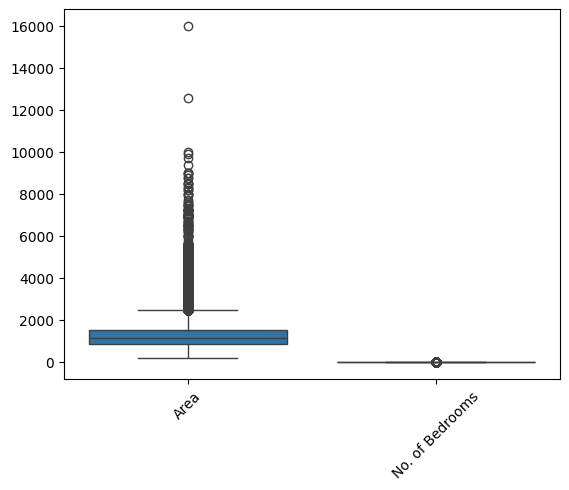

In [36]:
sns.boxplot(data=df[['Area', 'No. of Bedrooms']])
plt.xticks(rotation=45)
plt.show()

In [39]:
df.columns

Index(['Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale',
       'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens',
       'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall',
       'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School',
       '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter',
       'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine',
       'Gasconnection', 'AC', 'Wifi', 'Children'splayarea', 'LiftAvailable',
       'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV',
       'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator', 'city'],
      dtype='object')

In [51]:
df_copy = df.copy()

In [52]:
basic = [
    "LiftAvailable", "24X7Security", "PowerBackup", "CarParking",
    "Intercom", "Gasconnection", "VaastuCompliant", "MaintenanceStaff",
    "Wardrobe", "BED", "DiningTable", "Sofa", "TV", "Microwave", "Refrigerator"
]

intermediate = [
    "SwimmingPool", "Gymnasium", "LandscapedGardens", "JoggingTrack",
    "IndoorGames", "ShoppingMall", "ATM", "ClubHouse", "School",
    "Cafeteria", "MultipurposeRoom", "Hospital", "WashingMachine",
    "AC", "Wifi"
]

elite = [
     "RainWaterHarvesting", "SportsFacility",
    "Children'splayarea", "StaffQuarter", "GolfCourse"
]

df_copy['basic_score'] = df_copy[basic].sum(axis=1)
df_copy['intermediate_score'] = df_copy[intermediate].sum(axis=1)
df_copy['elite_score'] = df_copy[elite].sum(axis=1)


# setting the threshold to 50%
df_copy['basic_amenities'] = (df_copy['basic_score'] >= len(basic)*0.5).astype(int)
df_copy['intermediate_amenties'] = (df_copy['intermediate_score'] >= len(intermediate)*0.5).astype(int)
df_copy['elite_amenities'] = (df_copy['elite_score'] >= len(elite)*0.5).astype(int)

In [53]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29135 entries, 0 to 32962
Data columns (total 47 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Price                  29135 non-null  int64 
 1   Area                   29135 non-null  int64 
 2   Location               29135 non-null  object
 3   No. of Bedrooms        29135 non-null  int64 
 4   Resale                 29135 non-null  int64 
 5   MaintenanceStaff       29135 non-null  int64 
 6   Gymnasium              29135 non-null  int64 
 7   SwimmingPool           29135 non-null  int64 
 8   LandscapedGardens      29135 non-null  int64 
 9   JoggingTrack           29135 non-null  int64 
 10  RainWaterHarvesting    29135 non-null  int64 
 11  IndoorGames            29135 non-null  int64 
 12  ShoppingMall           29135 non-null  int64 
 13  Intercom               29135 non-null  int64 
 14  SportsFacility         29135 non-null  int64 
 15  ATM                    2

In [54]:
cols = ['city' , 'Area', 'Location', 'No. of Bedrooms','Resale','basic_amenities', 'intermediate_amenties', 'elite_amenities','Price']
df_copy = df_copy[cols]

In [55]:
df_copy.head()

,city,Area,Location,No. of Bedrooms,Resale,basic_amenities,intermediate_amenties,elite_amenities,Price
0,Bangalore,3340,JP Nagar Phase 1,4,0,0,0,1,30000000
1,Bangalore,1045,Dasarahalli on Tumkur Road,2,0,0,0,1,7888000
2,Bangalore,1179,Kannur on Thanisandra Main Road,2,0,0,0,0,4866000
3,Bangalore,1675,Doddanekundi,3,0,0,0,0,8358000
4,Bangalore,1670,Kengeri,3,0,0,0,1,6845000


In [60]:
df_copy.to_csv('../data/cleaned/final_cleaned_merged.csv', index=False)

In [74]:
final_df = pd.read_csv('../data/cleaned/final_cleaned_merged.csv')
final_df.head()

,city,Area,Location,No. of Bedrooms,Resale,basic_amenities,intermediate_amenties,elite_amenities,Price
0,Bangalore,3340,JP Nagar Phase 1,4,0,0,0,1,30000000
1,Bangalore,1045,Dasarahalli on Tumkur Road,2,0,0,0,1,7888000
2,Bangalore,1179,Kannur on Thanisandra Main Road,2,0,0,0,0,4866000
3,Bangalore,1675,Doddanekundi,3,0,0,0,0,8358000
4,Bangalore,1670,Kengeri,3,0,0,0,1,6845000


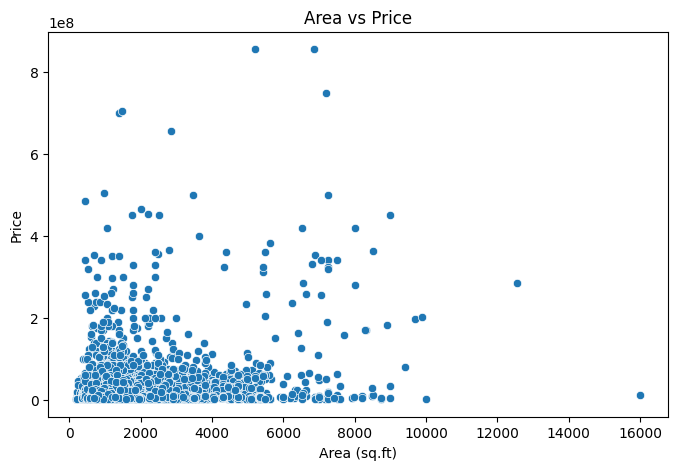

In [75]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=final_df, x='Area', y='Price')
plt.title('Area vs Price')
plt.xlabel('Area (sq.ft)')
plt.ylabel('Price')
plt.show()

In [76]:
final_df['Price'].max()

np.int64(854599999)

In [77]:
def human_readable_price(price):
        if price >= 1e7:  # Crores
            return f"{price/1e7:.2f} Crores"
        elif price >= 1e5:  # Lakhs
            return f"{price/1e5:.2f} Lakhs"
        else:
            return f"{price:,}"

In [78]:
final_df.head()

,city,Area,Location,No. of Bedrooms,Resale,basic_amenities,intermediate_amenties,elite_amenities,Price
0,Bangalore,3340,JP Nagar Phase 1,4,0,0,0,1,30000000
1,Bangalore,1045,Dasarahalli on Tumkur Road,2,0,0,0,1,7888000
2,Bangalore,1179,Kannur on Thanisandra Main Road,2,0,0,0,0,4866000
3,Bangalore,1675,Doddanekundi,3,0,0,0,0,8358000
4,Bangalore,1670,Kengeri,3,0,0,0,1,6845000


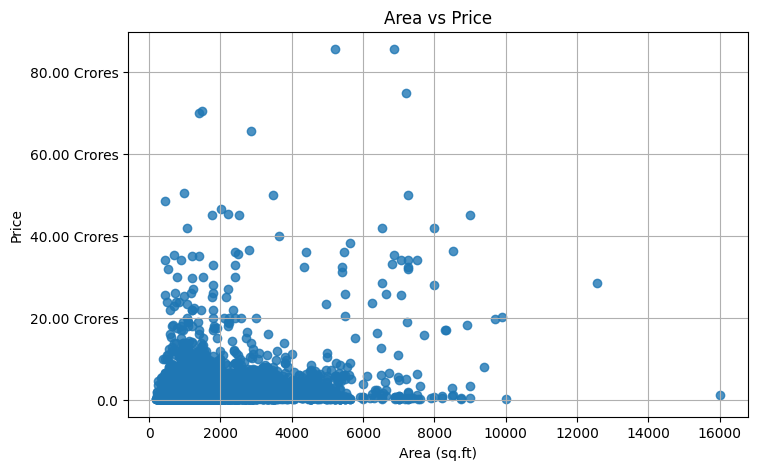

In [90]:
from matplotlib.ticker import FuncFormatter

# Define the formatter function using your human_readable_price
def y_axis_formatter(x, pos):
    return human_readable_price(x)

# Create the plot
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(final_df['Area'], final_df['Price'],alpha=0.8)

# Apply the formatter
ax.yaxis.set_major_formatter(FuncFormatter(y_axis_formatter))

ax.set_title('Area vs Price')
ax.set_xlabel('Area (sq.ft)')
ax.set_ylabel('Price')
plt.grid(True)
plt.show()